# Clasificación de dígitos mediante SVM

**Estudiante:** Manicaotex Mueses  
**Asignatura:** INF-8239 Ciencia de Datos II  
**Unidad:** 01 - Modelos avanzados, reducción dimensional y Green AI  
**Código:** U01.E01  

## Pregunta de análisis

¿Con qué nivel de rendimiento puede una máquina de vectores de soporte clasificar imágenes de dígitos escritos a mano?

## Unidad de análisis

Cada observación representa una imagen de 8 × 8 píxeles correspondiente a un dígito escrito a mano.

## Variable objetivo

La variable objetivo es el número representado en la imagen, con diez clases posibles: 0, 1, 2, 3, 4, 5, 6, 7, 8 y 9.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

digits = load_digits()

X = pd.DataFrame(digits.data, columns=digits.feature_names)
y = pd.Series(digits.target, name="digito")

print("Dimensiones de X:", X.shape)
print("\nCantidad por clase:")
print(y.value_counts().sort_index())

X.head()

Dimensiones de X: (1797, 64)

Cantidad por clase:
digito
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [2]:
auditoria = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "unicos": X.nunique()
})

print("Filas duplicadas:", X.duplicated().sum())
print("Valores ausentes totales:", X.isna().sum().sum())
print("¿La variable objetivo está dentro de X?:", y.name in X.columns)

auditoria.head(10)

Filas duplicadas: 0
Valores ausentes totales: 0
¿La variable objetivo está dentro de X?: False


,tipo,ausentes,unicos
pixel_0_0,float64,0,1
pixel_0_1,float64,0,9
pixel_0_2,float64,0,17
pixel_0_3,float64,0,17
pixel_0_4,float64,0,17
pixel_0_5,float64,0,17
pixel_0_6,float64,0,17
pixel_0_7,float64,0,16
pixel_1_0,float64,0,3
pixel_1_1,float64,0,17


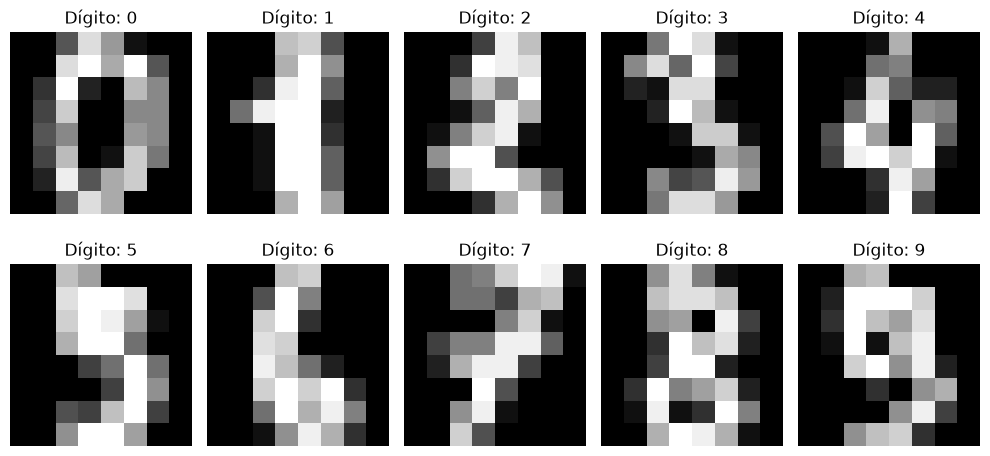

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Dígito: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

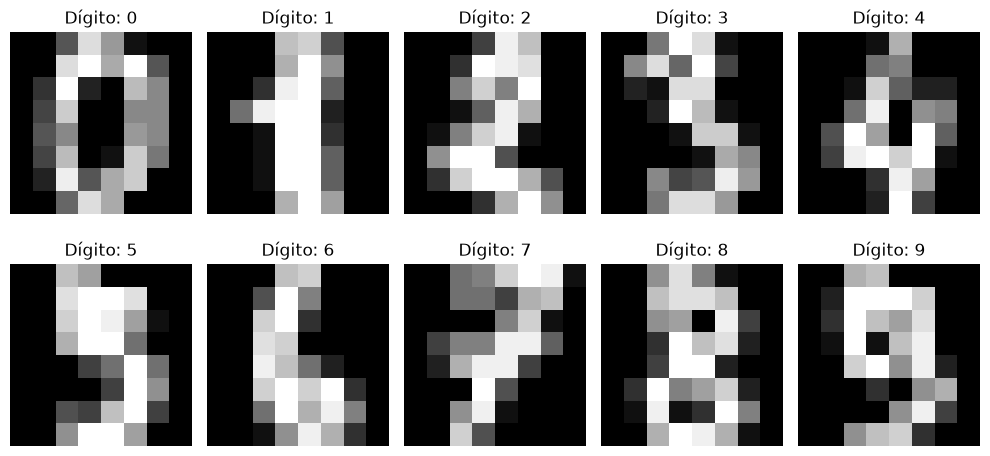

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Dígito: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


In [7]:
digits = load_digits()

X = pd.DataFrame(
    digits.data,
    columns=digits.feature_names
)

y = pd.Series(
    digits.target,
    name="digito"
)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Clases:", sorted(y.unique()))

Dimensiones de X: (1797, 64)
Dimensiones de y: (1797,)
Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_validation.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (1257, 64)
Validación: (270, 64)
Prueba: (270, 64)


In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

print("Pipeline creado correctamente")

Pipeline creado correctamente


In [10]:
parametros = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1]
}

busqueda = GridSearchCV(
    estimator=pipeline,
    param_grid=parametros,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

busqueda.fit(X_train, y_train)

print("Mejores parámetros:", busqueda.best_params_)
print(
    "Mejor exactitud en validación cruzada:",
    busqueda.best_score_
)

Mejores parámetros: {'svm__C': 1, 'svm__gamma': 'scale'}
Mejor exactitud en validación cruzada: 0.9824985771200911
